In [33]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# carregando modelo pré-treinado do Hugging Face
processor = AutoImageProcessor.from_pretrained("umm-maybe/AI-image-detector")
model = AutoModelForImageClassification.from_pretrained("umm-maybe/AI-image-detector")
model = model.to(device)
model.eval()

print("Classes do modelo:", model.config.id2label)

Classes do modelo: {0: 'artificial', 1: 'human'}


In [34]:
# carrega dataset - imagem
path = kagglehub.dataset_download("cashbowman/ai-generated-images-vs-real-images")
# pega a primeira imagem que encontrar
img_path = next(Path(path).rglob("*.jpg"))
image = Image.open(img_path).convert("RGB")

print("Imagem usada:", img_path)

Using Colab cache for faster access to the 'ai-generated-images-vs-real-images' dataset.
Imagem usada: /kaggle/input/ai-generated-images-vs-real-images/RealArt/RealArt/portrait-smiling-middle-aged-african-260nw-2088822202.jpg


In [35]:
# pré-processa a imagem
inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

inputs["pixel_values"].requires_grad = True


In [36]:
# função de ataque FGSM
def fgsm_attack(image, epsilon, grad):
    sign_grad = grad.sign()
    # x_adv = x + epsilon * sign(gradiente)
    perturbed_image = image + epsilon * sign_grad
    # não usamos clamp(0,1) aqui porque a imagem está normalizada (tem valores negativos)
    return perturbed_image

In [37]:
# previsão original e cálculo do gradiente
outputs = model(**inputs)

orig_probs = torch.softmax(outputs.logits, dim=1)
orig_pred = orig_probs.argmax(dim=1).item()
orig_conf = orig_probs[0, orig_pred].item()
orig_label = model.config.id2label[orig_pred]

print(f"Original --> {model.config.id2label[orig_pred]} ({orig_conf:.4f})")

# cálculo do erro
loss = torch.nn.CrossEntropyLoss()(
    outputs.logits,
    outputs.logits.argmax(dim=1)
)

model.zero_grad()
loss.backward()

Original --> human (0.9063)


In [38]:
# aplicação do ataque FGSM
epsilon = 0.1 # inicialmente em 0.1, mas podemos aumentar
perturbed_data = fgsm_attack(inputs["pixel_values"], epsilon, inputs["pixel_values"].grad)

In [39]:
# pós ataque
with torch.no_grad():
    adv_outputs = model(pixel_values=perturbed_data)

adv_probs = torch.softmax(adv_outputs.logits, dim=1)
adv_pred_idx = adv_probs.argmax(dim=1).item()
adv_label = model.config.id2label[adv_pred_idx]
adv_conf = adv_probs[0, adv_pred_idx].item()

print(f"Pós-Ataque: {adv_label} ({adv_conf:.2%})")

if orig_label != adv_label:
    print("Success! A IA foi enganada.")
else:
    print("A IA resistiu. Tente aumentar o epsilon.")

Pós-Ataque: artificial (91.06%)
Success! A IA foi enganada.


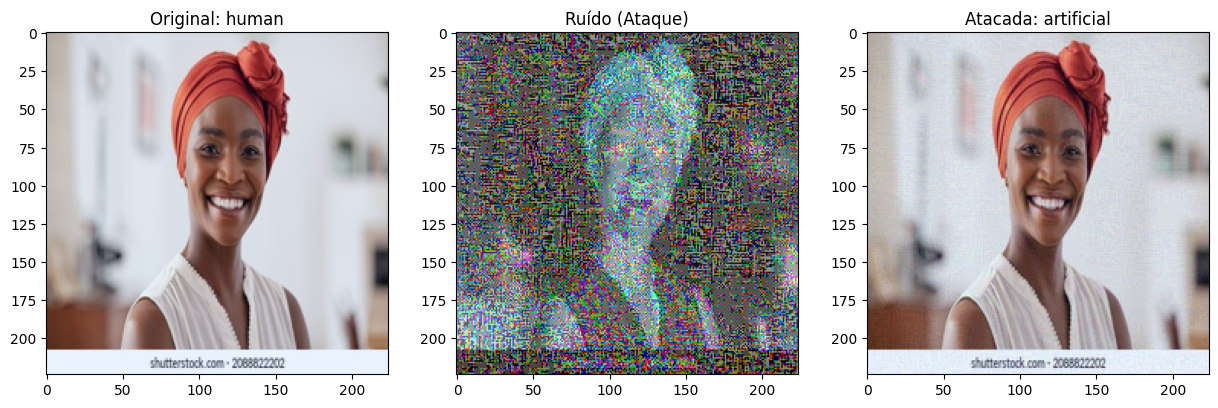

In [40]:
def show_comparison():
    # tira da GPU e converte para numpy
    orig_img = inputs["pixel_values"].detach().cpu().squeeze().permute(1, 2, 0).numpy()
    adv_img = perturbed_data.detach().cpu().squeeze().permute(1, 2, 0).numpy()
    
    # normaliza entre 0 e 1 apenas para mostrar na tela (Matplotlib) para não ter cores estranhas
    orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())
    adv_img = (adv_img - adv_img.min()) / (adv_img.max() - adv_img.min())
    
    # cálculo do ruído
    noise = adv_img - orig_img
    noise = (noise - noise.min()) / (noise.max() - noise.min()) # Aumenta contraste do ruído

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(orig_img); ax[0].set_title(f"Original: {orig_label}")
    ax[1].imshow(noise); ax[1].set_title("Ruído (Ataque)")
    ax[2].imshow(adv_img); ax[2].set_title(f"Atacada: {adv_label}")
    plt.show()

show_comparison()